# Сигналы дружеской связи в Telegram-переписке

**Исследовательский вопрос:** насколько частота сообщений, баланс участия, время ответа, инициирование разговоров и тематическая лексика позволяют описать изменение интенсивности и взаимности общения во времени?

Это case study цифрового диалога, а не психологическая диагностика. Метрики описывают наблюдаемое коммуникативное поведение.

## Данные и этика

Тетрадка по умолчанию использует синтетический `example_result.json`. Для итогового исследования укажите путь к обезличенному личному экспорту в `DATA_PATH`. Не публикуйте приватную переписку без согласия второго участника.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from app.analyzer.parser import parse_telegram_export
from app.analyzer.metrics import build_metrics, build_timeseries
from app.analyzer.topics import build_topics
from app.analyzer.network import build_network

DATA_PATH = ROOT / 'data' / 'example_result.json'
df = parse_telegram_export(DATA_PATH.read_bytes())
print(f'Сообщений: {len(df):,}')
print(f'Период: {df.date.min():%d.%m.%Y} — {df.date.max():%d.%m.%Y}')
print('Участники:', ', '.join(df.sender.unique()))

Сообщений: 24
Период: 05.01.2024 — 20.04.2024
Участники: Участник A, Участник B


## 1. Предобработка

Парсер оставляет текстовые сообщения, приводит даты к `datetime`, разворачивает сложное поле Telegram `text`, очищает URL и упоминания регулярными выражениями и вычисляет длину сообщения.

In [2]:
df[['date', 'sender', 'text', 'clean_text', 'word_count']].head()

,date,sender,text,clean_text,word_count
0,2024-01-05 10:00:00,Участник A,Привет! Как прошла первая неделя?,привет как прошла первая неделя,5
1,2024-01-05 10:08:00,Участник B,"Привет, хорошо. Начал новый учебный проект.",привет хорошо начал новый учебный проект,6
2,2024-01-05 10:12:00,Участник A,Расскажешь про проект вечером?,расскажешь про проект вечером,4
3,2024-01-05 10:25:00,Участник B,"Да, давай созвонимся после восьми.",да давай созвонимся после восьми,5
4,2024-01-18 18:20:00,Участник B,Как твоя презентация? Нужна помощь?,как твоя презентация нужна помощь,5


## 2. Описательные метрики

Коэффициент взаимности — отношение числа сообщений менее активного из двух основных участников к числу сообщений более активного. Он оценивает баланс объема, но не качество отношений. Старт эпизода определяется как первое сообщение после паузы более шести часов.

In [3]:
metrics = build_metrics(df)
pd.DataFrame(metrics['by_sender']).style.format({'share': '{:.1%}', 'avg_words': '{:.1f}'})

,sender,messages,share,avg_words,questions
0,Участник A,12,50.0%,6.2,7
1,Участник B,12,50.0%,5.2,3


In [4]:
print('Коэффициент взаимности:', metrics['reciprocity_score'])
print('Старты после паузы > 6 часов:', metrics['conversation_starters_after_6h'])
print('Среднее время ответа, минут:', metrics['avg_reply_minutes'])

Коэффициент взаимности: 1.0
Старты после паузы > 6 часов: {'Участник B': 5, 'Участник A': 4}
Среднее время ответа, минут: {'Участник B': 63.6, 'Участник A': 8.3}


## 3. Динамика активности

Сравнение месяцев позволяет проверить, стабильно ли общение или концентрируется в отдельных периодах. Для реального корпуса следует интерпретировать пики вместе с известным контекстом, не выводя причины только из графика.

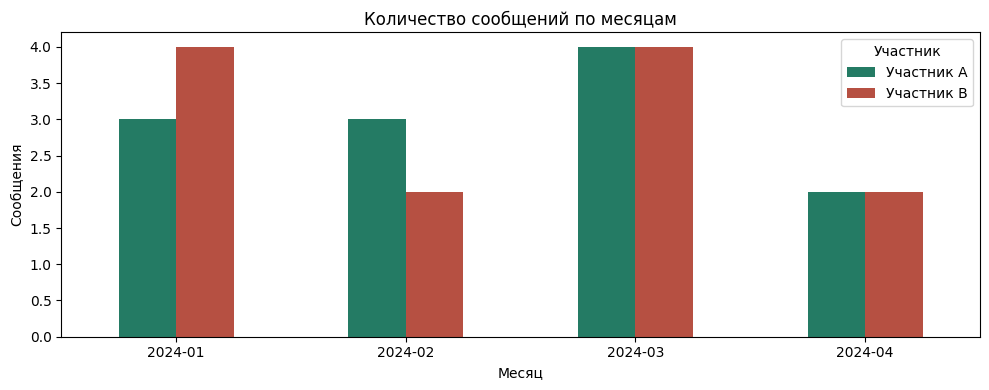

In [5]:
monthly = pd.DataFrame(build_timeseries(df)['monthly'])
monthly_pivot = monthly.pivot(index='month', columns='sender', values='messages').fillna(0)
ax = monthly_pivot.plot(kind='bar', figsize=(10, 4), color=['#247b64', '#b65042'])
ax.set(title='Количество сообщений по месяцам', xlabel='Месяц', ylabel='Сообщения')
ax.legend(title='Участник')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Частотный анализ и TF-IDF

Частотный список показывает общую лексику корпуса. TF-IDF сравнивает объединенные документы участников и поднимает слова, относительно характерные для каждого автора. При двух документах результат чувствителен к объему корпуса и словоформам.

In [6]:
topics = build_topics(df)
top_words = pd.DataFrame(topics['top_words'], columns=['слово', 'частота'])
display(top_words.head(15))

for sender, terms in topics['tfidf_by_sender'].items():
    print(f'\n{sender}:', ', '.join(term for term, score in terms[:10]))

,слово,частота
0,спасибо,4
1,давай,3
2,привет,2
3,прошла,2
4,неделя,2
5,хорошо,2
6,проект,2
7,вечером,2
8,после,2
9,выставка,2



Участник A: прошла, вечером, графики, спасибо, первая, расскажешь, про, почти, готово, можешь

Участник B: давай, после, была, спасибо, начал, новый, учебный, созвонимся, восьми, презентация


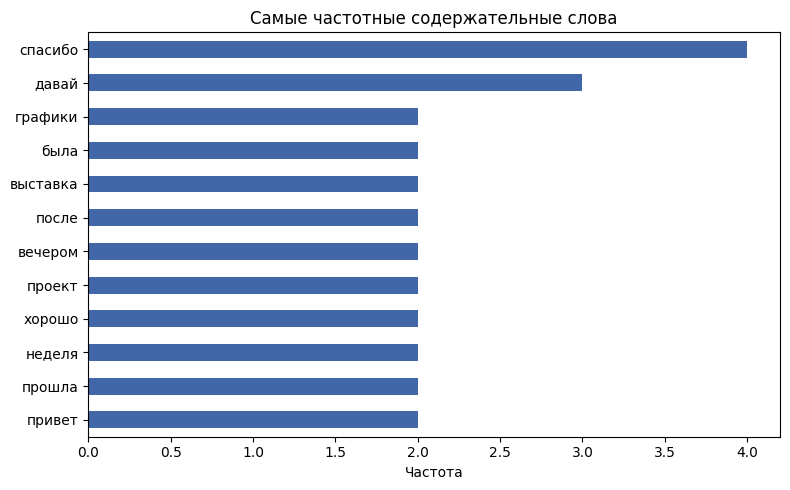

In [7]:
plot_words = top_words.head(12).sort_values('частота')
ax = plot_words.plot.barh(x='слово', y='частота', legend=False, figsize=(8, 5), color='#4267a8')
ax.set(title='Самые частотные содержательные слова', xlabel='Частота', ylabel='')
plt.tight_layout()
plt.show()

## 5. Сетевой анализ

Узлы — авторы, ребро показывает переход от автора предыдущего сообщения к автору следующего. Петли обозначают серии сообщений одного автора, встречные ребра — смену очереди. Для диалога из двух человек граф прост, но его веса позволяют сравнивать чередование реплик и монологические серии.

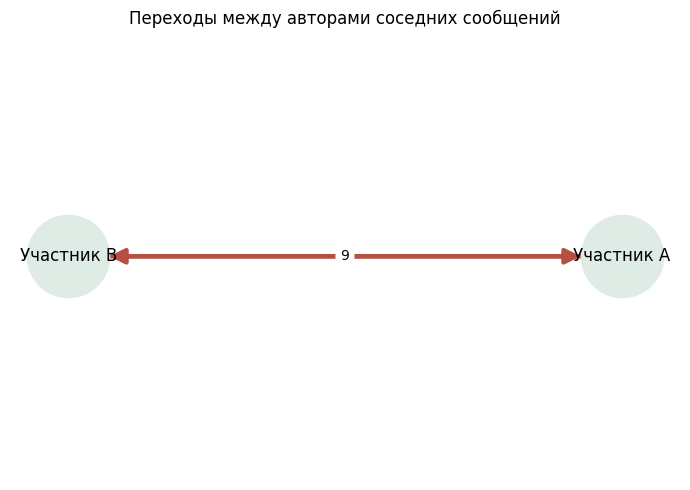

In [8]:
network = build_network(df)
G = nx.DiGraph()
for edge in network['edges']:
    G.add_edge(edge['source'], edge['target'], weight=edge['weight'])

pos = nx.circular_layout(G)
weights = [1 + G[u][v]['weight'] / 4 for u, v in G.edges()]
plt.figure(figsize=(7, 5))
nx.draw_networkx(G, pos, node_color='#dfece5', edge_color='#b65042', width=weights, node_size=3500, arrowsize=22)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title('Переходы между авторами соседних сообщений')
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Интерпретация пилота

На синтетическом корпусе участие намеренно сбалансировано, а реплики часто чередуются. Пайплайн поэтому должен показать высокую взаимность и встречные ребра большого веса. Темы учебного проекта, встреч и поддержки повторяются у обоих участников. Это проверка корректности метода, а не эмпирический вывод.

После запуска на реальном обезличенном корпусе замените этот абзац ответами на четыре вопроса:

1. В какие периоды активность была максимальной и минимальной?
2. Совпадают ли баланс сообщений, скорость ответов и инициирование эпизодов?
3. Какие темы общие, а какие характерны каждому участнику?
4. Какие наблюдения нельзя объяснить без внешнего контекста?

## 7. Ограничения

- Переписка не отражает офлайн-встречи, удаленные сообщения и чтение без ответа.
- Поведенческие признаки зависят от расписания и платформенных привычек.
- TF-IDF не распознает иронию и контекст.
- Один диалог не позволяет статистическое обобщение.
- Сводный индекс нельзя интерпретировать как процент дружбы.
- LLM-текст является гипотезой для чтения результатов, а не доказательством.